In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, make_moons, make_regression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, classification_report, mean_squared_error, r2_score
)

np.random.seed(42)
sns.set_style("whitegrid")

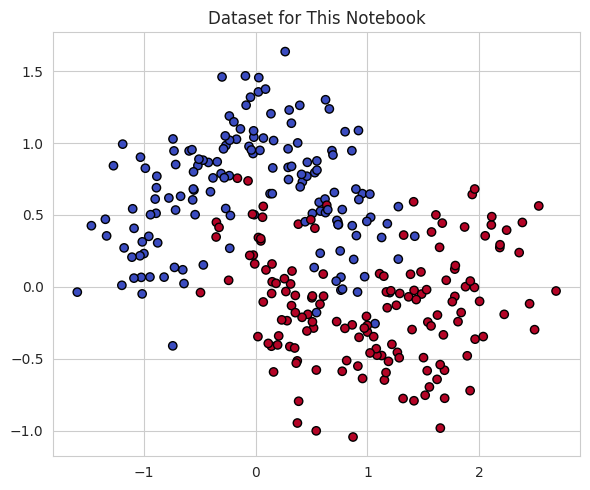

In [2]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.title("Dataset for This Notebook")
plt.tight_layout()
plt.show()


In [7]:
def entropy(labels):
  if len(labels) == 0:
    return 0
  counts = np.unique(labels, return_counts=True)[1]
  probs = counts / len(labels)
  return -np.sum(probs * np.log2(probs))

thresholds_to_try = [-1.0, -0.5, 0.0, 0.5, 1.0, 1.5]
parent_entropy = entropy(y_train)
print(f"Parent entropy: {parent_entropy:.3f}")

for t in thresholds_to_try:
  left_mask = X_train[:,0] <= t
  right_mask = ~left_mask
  left_labels, right_labels = y_train[left_mask], y_train[right_mask]

  if len(left_labels) == 0 or len(right_labels) == 0:
    continue

  weighted_entropy = (
      len(left_labels) / len(y_train) * entropy(left_labels) +
      len(right_labels) / len(y_train) * entropy(right_labels)
      )
  gain = parent_entropy - weighted_entropy
  print(f"Threshold x1 <= {t:5.1f}:  weighted Entropy = {weighted_entropy:.3f},  gain = {gain:.3f}")


Parent entropy: 1.000
Threshold x1 <=  -1.0:  weighted Entropy = 0.939,  gain = 0.061
Threshold x1 <=  -0.5:  weighted Entropy = 0.828,  gain = 0.172
Threshold x1 <=   0.0:  weighted Entropy = 0.810,  gain = 0.190
Threshold x1 <=   0.5:  weighted Entropy = 0.904,  gain = 0.096
Threshold x1 <=   1.0:  weighted Entropy = 0.790,  gain = 0.210
Threshold x1 <=   1.5:  weighted Entropy = 0.819,  gain = 0.181


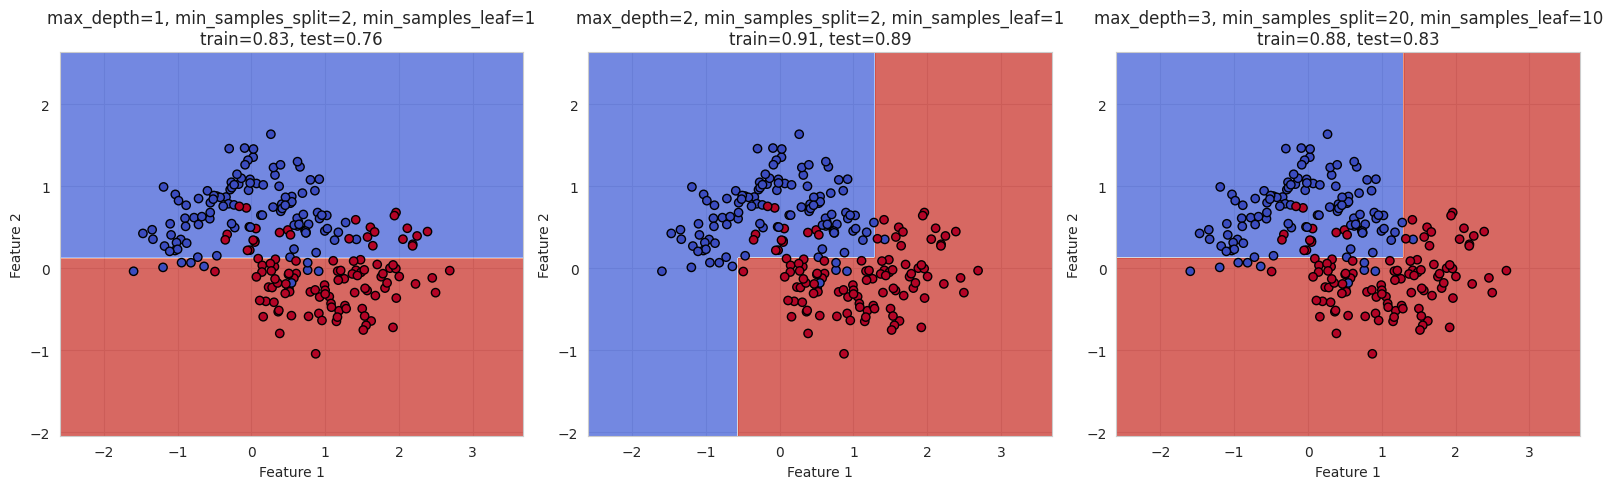

In [10]:
def plot_decision_boundary(model, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.8, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

hyperparam_sets = [
    {"max_depth": 1, "min_samples_split": 2, "min_samples_leaf": 1},   # unrestricted
    {"max_depth": 2,    "min_samples_split": 2, "min_samples_leaf": 1},
    {"max_depth": 3, "min_samples_split": 20, "min_samples_leaf": 10},
    {"max_depth": 4, "min_samples_split": 3, "min_samples_leaf": 15},
    {"max_depth": 5, "min_samples_split": 20, "min_samples_leaf": 10},
    {"max_depth": 6, "min_samples_split": 2, "min_samples_leaf": 1},
    {"max_depth": 7, "min_samples_split": 2, "min_samples_leaf": 1},
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, params in zip(axes, hyperparam_sets):
    model = DecisionTreeClassifier(random_state=42, **params)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    label = ", ".join(f"{k}={v}" for k, v in params.items())
    plot_decision_boundary(model, X_train, y_train,
                            f"{label}\ntrain={train_acc:.2f}, test={test_acc:.2f}", ax=ax)
plt.tight_layout()
plt.show()

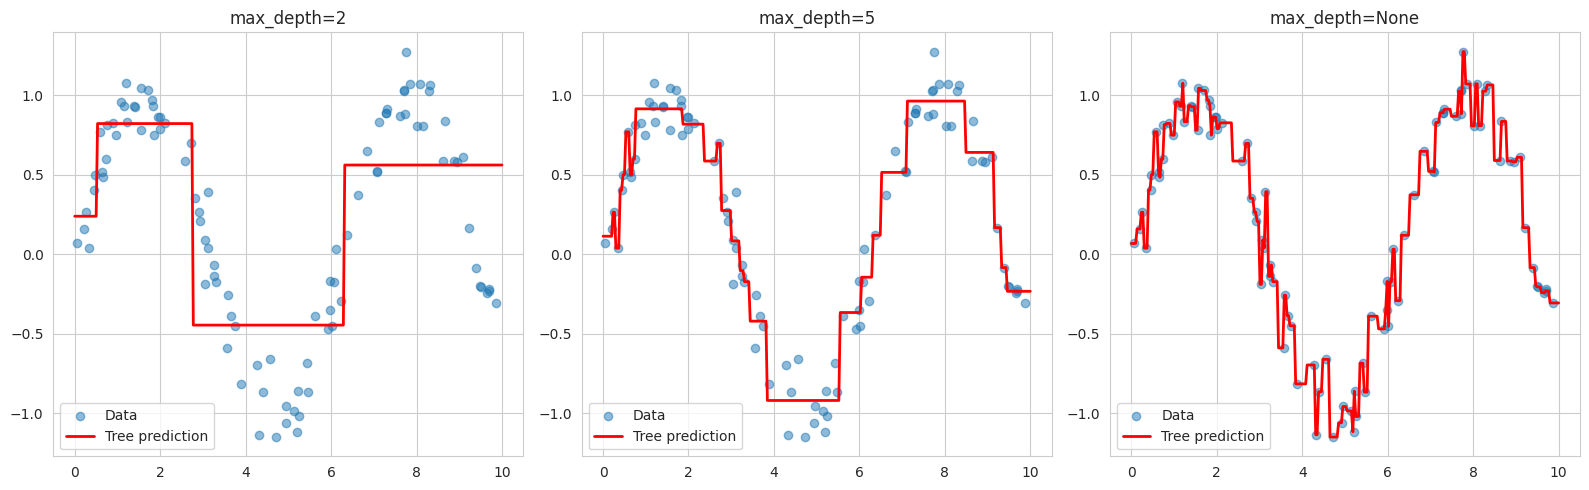

In [11]:
X_reg = np.sort(np.random.uniform(0, 10, 100)).reshape(-1, 1)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.15, 100)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, depth in zip(axes, [2, 5, None]):
    reg_tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    reg_tree.fit(X_reg, y_reg)

    X_smooth = np.linspace(0, 10, 300).reshape(-1, 1)
    y_smooth_pred = reg_tree.predict(X_smooth)

    ax.scatter(X_reg, y_reg, alpha=0.5, label="Data")
    ax.plot(X_smooth, y_smooth_pred, color="red", linewidth=2, label="Tree prediction")
    label = f"max_depth={depth}" if depth else "max_depth=None"
    ax.set_title(label)
    ax.legend()
plt.tight_layout()
plt.show()

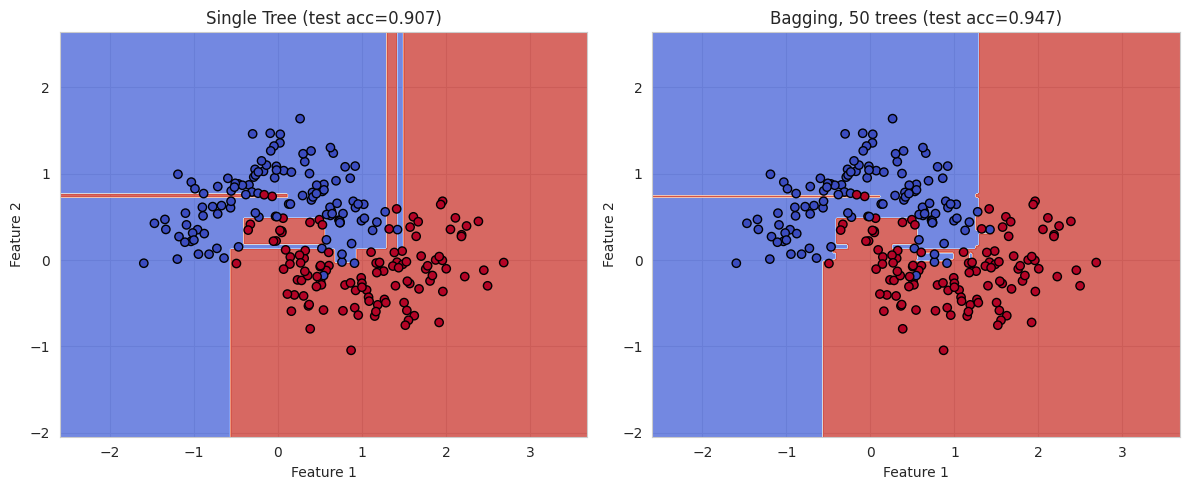

In [12]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=5,
    random_state=42
)
bagging_model.fit(X_train, y_train)

single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(single_tree, X_train, y_train,
                        f"Single Tree (test acc={accuracy_score(y_test, single_tree.predict(X_test)):.3f})",
                        ax=axes[0])
plot_decision_boundary(bagging_model, X_train, y_train,
                        f"Bagging, 50 trees (test acc={accuracy_score(y_test, bagging_model.predict(X_test)):.3f})",
                        ax=axes[1])
plt.tight_layout()
plt.show()

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_features= 1,   # each split considers only sqrt(n_features) features
    random_state=42,
    oob_score=True         # enables out-of-bag scoring, covered next
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(f"Random Forest test accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print()
print(classification_report(y_test, y_pred_rf))


Random Forest test accuracy: 0.933

              precision    recall  f1-score   support

           0       0.97      0.89      0.93        38
           1       0.90      0.97      0.94        37

    accuracy                           0.93        75
   macro avg       0.94      0.93      0.93        75
weighted avg       0.94      0.93      0.93        75



In [15]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_features= "sqrt",   # each split considers only sqrt(n_features) features
    random_state=42,
    oob_score=True         # enables out-of-bag scoring, covered next
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(f"Random Forest test accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print()
print(classification_report(y_test, y_pred_rf))


Random Forest test accuracy: 0.933

              precision    recall  f1-score   support

           0       0.97      0.89      0.93        38
           1       0.90      0.97      0.94        37

    accuracy                           0.93        75
   macro avg       0.94      0.93      0.93        75
weighted avg       0.94      0.93      0.93        75



In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_features= None,   # each split considers only sqrt(n_features) features
    random_state=42,
    oob_score=True         # enables out-of-bag scoring, covered next
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(f"Random Forest test accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print()
print(classification_report(y_test, y_pred_rf))


Random Forest test accuracy: 0.947

              precision    recall  f1-score   support

           0       0.97      0.92      0.95        38
           1       0.92      0.97      0.95        37

    accuracy                           0.95        75
   macro avg       0.95      0.95      0.95        75
weighted avg       0.95      0.95      0.95        75



In [17]:
from sklearn.model_selection import cross_val_score
import numpy as np

oob_score = rf_model.oob_score_

cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5
)

cv_mean = cv_scores.mean()

print(f"OOB Score: {oob_score:.4f}")
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_mean:.4f}")

difference = abs(oob_score - cv_mean)

print(f"Absolute Difference: {difference:.4f}")
print(f"Difference in percentage points: {difference * 100:.2f}%")


OOB Score: 0.8844
CV Scores: [0.91111111 0.84444444 0.91111111 0.91111111 0.88888889]
Mean CV Accuracy: 0.8933
Absolute Difference: 0.0089
Difference in percentage points: 0.89%


/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


n_estimators=  1 | OOB Score=0.6311
n_estimators=  5 | OOB Score=0.8222
n_estimators= 20 | OOB Score=0.9022
n_estimators= 50 | OOB Score=0.9111
n_estimators=100 | OOB Score=0.9067
n_estimators=200 | OOB Score=0.8978


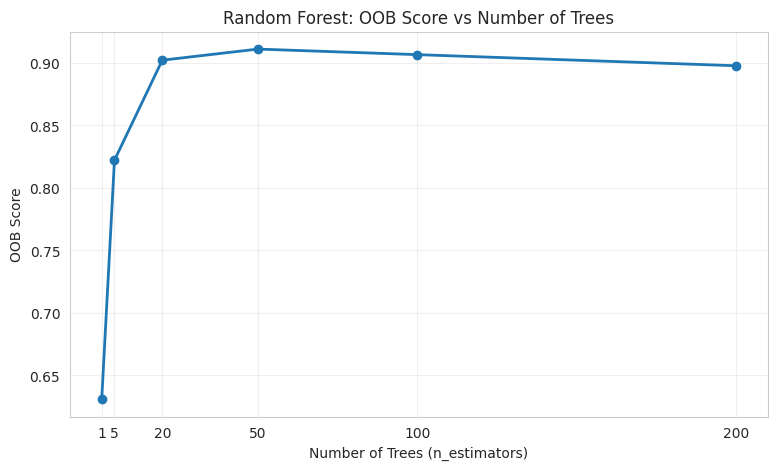

In [18]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

n_estimators_values = [1, 5, 20, 50, 100, 200]
oob_scores = []

for n in n_estimators_values:
    rf = RandomForestClassifier(
        n_estimators=n,
        oob_score=True,
        random_state=42,
        bootstrap=True
    )

    rf.fit(X_train, y_train)

    oob_scores.append(rf.oob_score_)

    print(f"n_estimators={n:3d} | OOB Score={rf.oob_score_:.4f}")
plt.figure(figsize=(9, 5))

plt.plot(
    n_estimators_values,
    oob_scores,
    marker='o',
    linewidth=2
)

plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("OOB Score")
plt.title("Random Forest: OOB Score vs Number of Trees")
plt.xticks(n_estimators_values)
plt.grid(True, alpha=0.3)

plt.show()